In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_groq import ChatGroq
from pydantic import BaseModel
from dotenv import load_dotenv
import os

load_dotenv()

True

In [5]:
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
GROQ_MODEL=os.getenv("GROQ_MODEL")

In [6]:
model = ChatGroq(model=GROQ_MODEL, api_key=GROQ_API_KEY)

In [7]:
class StudentState(TypedDict):
    name: str
    marks: int
    grade: str
    message: str

In [8]:
def calculate_grade(state: StudentState):
    marks = state["marks"]
    
    if marks >= 80:
        return {"grade": "A"}
    elif marks >= 60:
        return {"grade": "B"}
    elif marks >= 40:
        return {"grade": "C"}
    else:
        return {"grade": "Fail"}
    
    
def a_grade_node(state: StudentState):

    return {
        "message": "Excellent work! Keep shining."
    }


def b_grade_node(state: StudentState):

    return {
        "message": "Good job! Keep improving."
    }


def c_grade_node(state: StudentState):

    return {
        "message": "You can do better with more practice."
    }


def fail_node(state: StudentState):

    return {
        "message": "Don't give up, keep trying and learning."
    }


def conditional_router(state: StudentState) -> Literal["A", "B", "C", "Fail"]:
    grade = state["grade"]
    
    if grade == "A":
        return "A"
    elif grade == "B":
        return "B"
    elif grade == "C":
        return "C"
    else:
        return "Fail"

In [9]:
graph = StateGraph(StudentState)

graph.add_node("calculate_grade", calculate_grade)
graph.add_node("A", a_grade_node)
graph.add_node("B", b_grade_node)
graph.add_node("C", c_grade_node)
graph.add_node("Fail", fail_node)

graph.add_edge(START, "calculate_grade")
graph.add_conditional_edges("calculate_grade", conditional_router)
graph.add_edge("A", END)
graph.add_edge("B", END)
graph.add_edge("C", END)
graph.add_edge("Fail", END)

workflow = graph.compile()

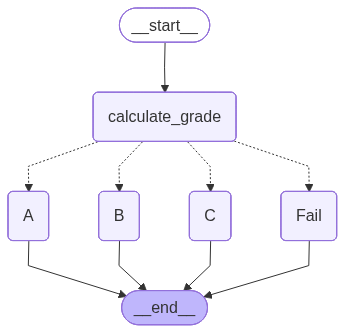

In [10]:
workflow

In [11]:
initial_state = {
    "name": "Ehsan",
    "marks": 85
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'name': 'Ehsan', 'marks': 85, 'grade': 'A', 'message': 'Excellent work! Keep shining.'}
